# Customer Churn Prediction - Data Overview

## 1. Project Background

Customer churn prediction is an important task in user growth analysis and customer relationship management.

The goal of this project is to identify customers who are likely to leave a service platform and analyze the factors influencing churn behavior.

## 2. Dataset Introduction

This project uses the IBM Telco Customer Churn dataset.

The dataset contains customer demographic information, service usage information, contract information, and billing information.

Each row represents one customer, and the target variable is `Churn`.

## 3. Objectives

The objectives of this exploratory analysis are:

- Understand the structure of the dataset
- Check data quality issues
- Analyze customer churn distribution
- Explore potential factors related to customer churn

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# 显示所有列
pd.set_option("display.max_columns", None)

# 图片大小
plt.rcParams["figure.figsize"] = (8, 5)

In [24]:
df = pd.read_csv(
    "../data/raw/telco_churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [25]:
df.shape

(7043, 21)

The dataset contains 7043 customer records and 21 variables.

The target variable is `Churn`, indicating whether a customer has left the service.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [27]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [28]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [29]:
df["TotalCharges"].unique()[:10]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95'], dtype=object)

In [30]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [31]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

The `TotalCharges` variable contains several empty string values.

These values are converted into missing values and will be handled during data preprocessing.

In [32]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [33]:
df["Churn"].value_counts(
    normalize=True
)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

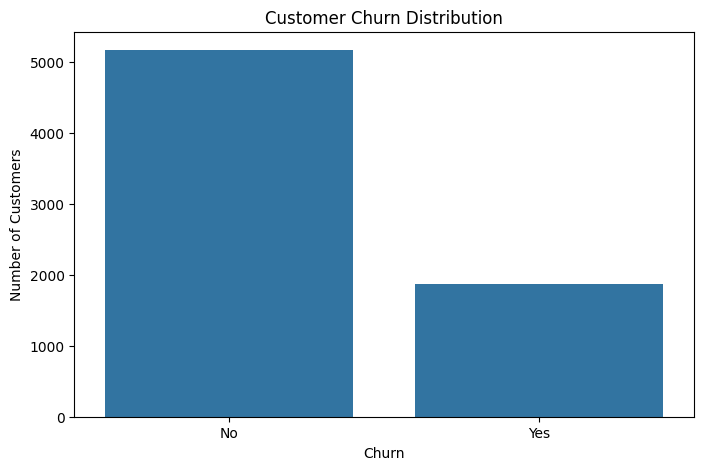

<Figure size 800x500 with 0 Axes>

In [34]:
sns.countplot(
    data=df,
    x="Churn"
)

plt.title(
    "Customer Churn Distribution"
)

plt.xlabel(
    "Churn"
)

plt.ylabel(
    "Number of Customers"
)

plt.show()

plt.savefig(
    "../reports/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

## Churn Distribution Analysis

The dataset contains 7032 valid customer records after removing missing values.

Approximately 26.6% of customers have churned, while 73.4% remain active.

The imbalance between churned and retained customers should be considered during model training.

In [35]:
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


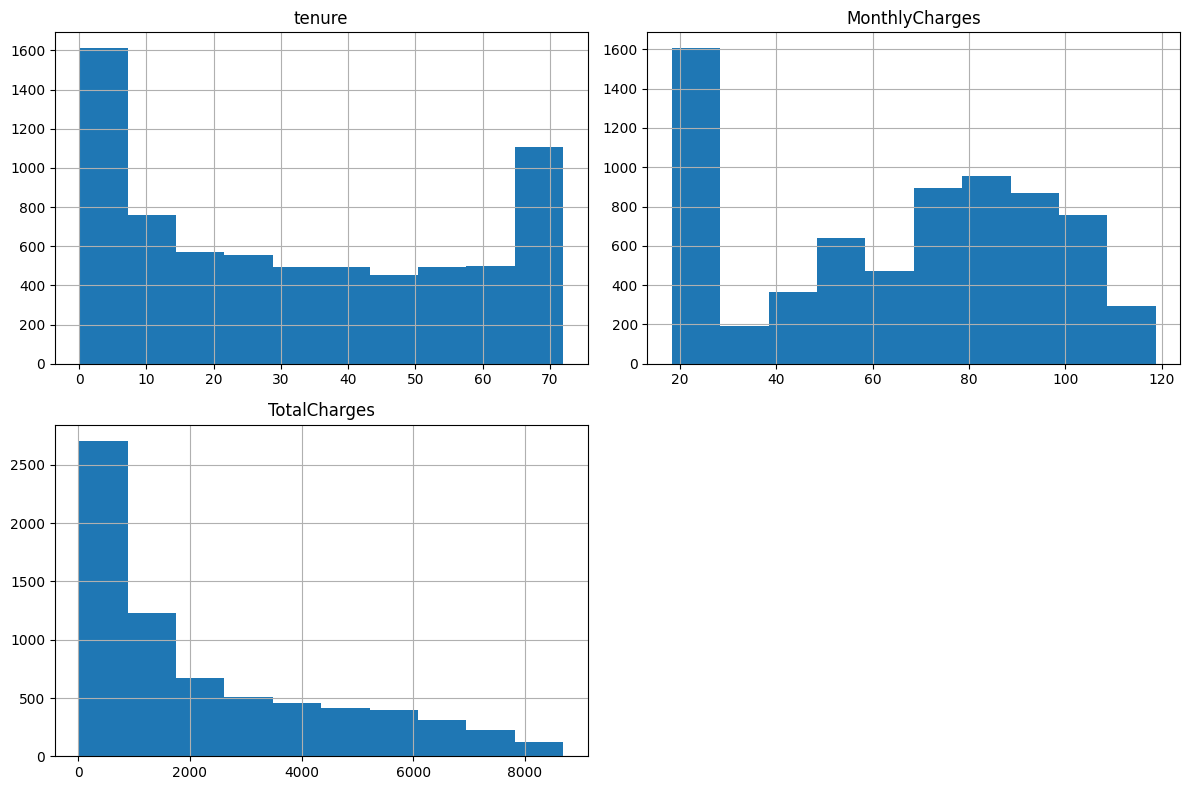

In [36]:
df[numeric_features].hist(
    figsize=(12,8)
)

plt.tight_layout()

plt.show()

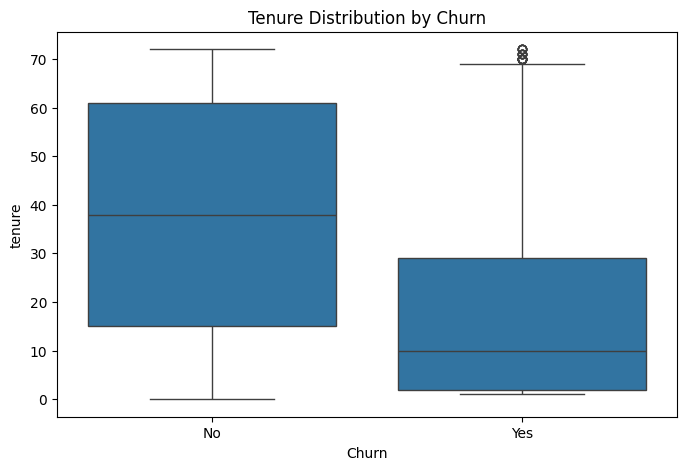

In [37]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title(
    "Tenure Distribution by Churn"
)

plt.show()

## 9. Contract Type Analysis

Contract type may strongly influence customer retention.
Customers with longer-term contracts usually have higher commitment.

In [38]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


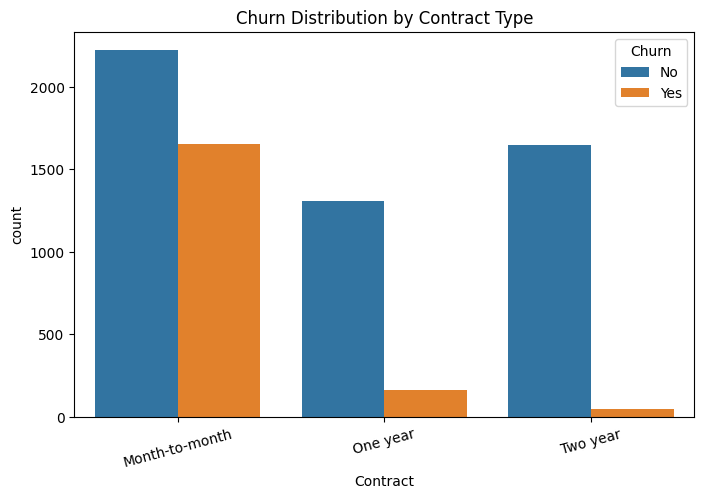

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title(
    "Churn Distribution by Contract Type"
)

plt.xticks(rotation=15)

plt.show()

### Observation

Customers with month-to-month contracts show a much higher churn rate compared with customers using one-year or two-year contracts.

Long-term contracts appear to improve customer retention.

## 10. Customer Tenure Analysis

Tenure represents how long a customer has used the service.